In [3]:
library(Seurat)
library(scop)
library(Signac)
library(ggplot2)
set.seed(4180)
library(patchwork)
setwd("/")
#########color
cols <- c("#444576", "#4682B4",
 "#AEDEEE","#FFA500",
 "#FFD790","#C65762","#FBDFDE",
 "#F6EFCF","#BCB99F")
pal <- colorRampPalette(cols)

Loading required package: SeuratObject

Loading required package: sp




Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Registered S3 method overwritten by 'scop':
  method             from  
  FoldChange.default Seurat

          ⬢          .        ⬡             ⬢     .
                     _____ _________  ____
                    / ___// ___/ __ ./ __ .
                   (__  )/ /__/ /_/ / /_/ /
                  /____/ .___/.____/ .___/
                                  /_/
      ⬢               .      ⬡        .          ⬢

------------------------------------------------------------
Version: 0.8.7 (2026-03-31 update)
Website: https://mengxu98.github.io/scop/

Python environment initialization is disabled
To enable it, set: options(scop_env_init = TRUE)

The message can be suppressed by: 
  suppressPackageStartupMessages(library(scop))
  or options(log_message.verbose = FALSE)
------------------------------------------------------------



In [2]:
subsc.list <- readRDS("data/subsc.list.Rds")

In [9]:
#S3
library(ComplexHeatmap)
library(dplyr)
cell.types <- c( "Macrophage", "aCM", "EndoCC",
 "Neuronal","Pericyte")
for(i in cell.types ) {
sc_obj <- subsc.list[[i]]
p1 <- CellDimPlot(
 srt = sc_obj, group.by = "subtype",
 legend.position = "right", label_repel = T,
 label_point_size = 0.1, reduction = "umap",
 label = F, label_insitu = T,
 theme_use = "theme_scop",
 palcolor = pal(4), raster = F,
 label.fg = "black", label.bg = "grey95",
 label.bg.r = 0
)
ggsave(
 plot = p1,
 filename = paste("S4_", i, "_umap.pdf", sep = ""),
 path = "plot/figureS4/",
 create.dir = TRUE, width = 4, height = 4
)
p2 <- CellStatPlot(sc_obj, stat.by = "subtype", group.by = "group",
 label = T,palcolor = pal(4),position ="dodge",
 plot_type = "bar",xlab = '',ylab = 'Percentage')
ggsave(
 plot = p2,
 filename = paste("S4_", i, "_CellStat.pdf", sep = ""),
 path = "plot/figureS4/",
 create.dir = TRUE, width = 6,height = 3
)
DefaultAssay(sc_obj) <- "RNA"
sc_obj <- RunDEtest(sc_obj,
 group.by = "subtype", fc.threshold = 1.1, cores = 4,
 assay = "RNA", only.pos = T, min.pct = 0.25
)
AllMarkers <- filter(
 sc_obj@tools$DEtest_subtype$AllMarkers_wilcox,
 p_val_adj < 0.05,
 test_group_number == 1
)
AllMarkers <- AllMarkers %>%
 filter(p_val_adj < 0.05) %>%
 group_by(group1) %>%
 arrange(desc(avg_log2FC)) %>%
 slice_head(n = 50)
AllMarkers$label <- rownames(AllMarkers)
result <- AllMarkers %>%
 filter(p_val_adj < 0.05) %>%
 group_by(group1) %>%
 arrange(desc(avg_log2FC)) %>%
 slice_head(n = 5)
ave.dt <- scale(
 t(as.matrix(AverageExpression(sc_obj[AllMarkers$gene, ],
 group.by = "subtype", assays = "RNA", layer = "data"
)$RNA)))
ave.dt <- ave.dt[, AllMarkers$gene]
ha <- HeatmapAnnotation(foo = anno_mark(
 at = as.numeric(result$label),
 labels = result$gene,
 labels_gp = gpar(fontsize = 10, rot = 45, fontface = "italic")
))
pdf(paste("plot/figureS4/S4_", i, "subtype_markers.pdf", sep = ""),
 width = 6, height = 3) # save as pdf file
draw(Heatmap(ave.dt,
 cluster_columns = F,
 cluster_rows = F, col = c("grey80", "white", "#444576"),
 show_column_names = F,
 heatmap_legend_param = list(
 title = "Expression", at = c(-2, 0, 2),
 labels = c("Min", "", "Max")
 ),
 top_annotation = ha, row_names_side = "left",
 width = unit(10, "cm"), height = unit(4, "cm")
))
dev.off()
}

ℹ [2026-05-09 19:16:40] Data type is log-normalized

ℹ [2026-05-09 19:16:40] Start differential expression test

ℹ [2026-05-09 19:16:40] Find all markers(wilcox) among [1] 6 groups...

ℹ [2026-05-09 19:16:40] Using 4 cores

⠙ [2026-05-09 19:16:40] Running for Macrophage-1... [2/6] ■■■         33% | ETA…

⠹ [2026-05-09 19:16:40] Running for Macrophage-2... [4/6] ■■■■■■      67% | ETA…

✔ [2026-05-09 19:16:40] Completed 6 tasks in 5.7s



ℹ [2026-05-09 19:16:40] Building results

✔ [2026-05-09 19:16:46] Differential expression test completed

ℹ [2026-05-09 19:16:48] Data type is log-normalized

ℹ [2026-05-09 19:16:48] Start differential expression test

ℹ [2026-05-09 19:16:48] Find all markers(wilcox) among [1] 4 groups...

ℹ [2026-05-09 19:16:48] Using 4 cores

⠙ [2026-05-09 19:16:48] Running for aCM-1... [1/4] ■■          25% | ETA:  1s

✔ [2026-05-09 19:16:48] Completed 4 tasks in 1.2s



ℹ [2026-05-09 19:16:48] Building results

✔ [2026-05-09 19:16:49] Differential expression test co

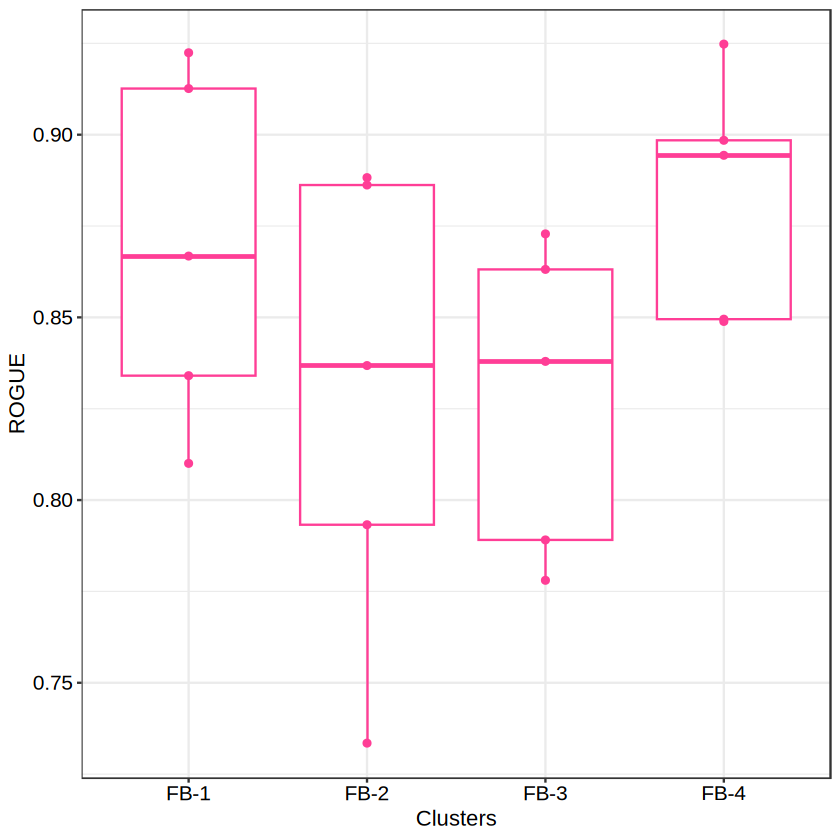

In [10]:
rogue.res <- readRDS("data/FBrogue.Rds")
p <- rogue.boxplot(rogue.res)
p

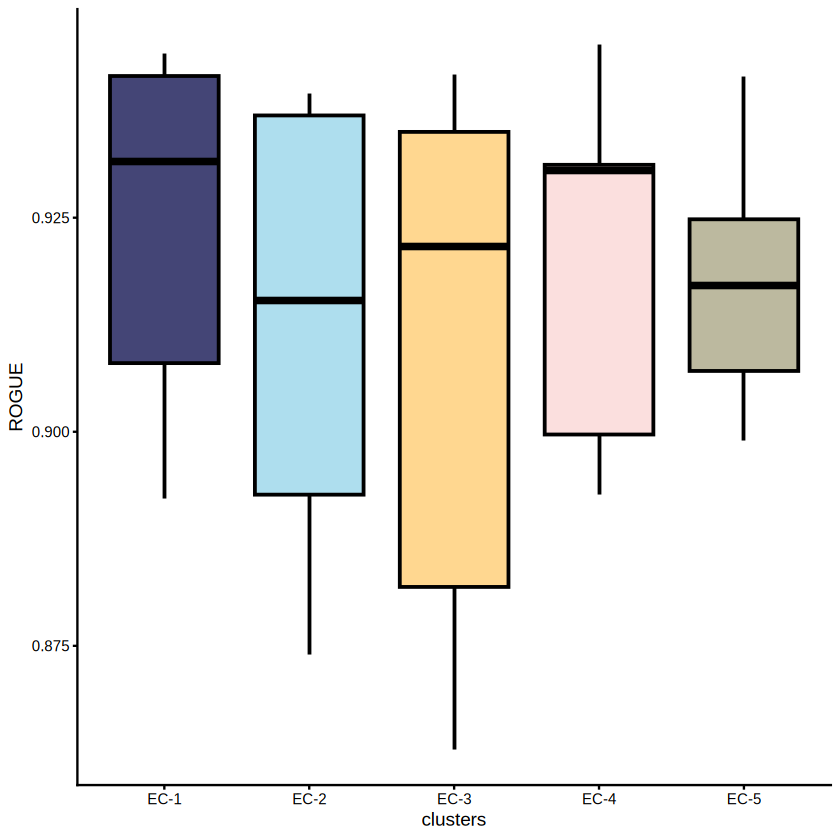

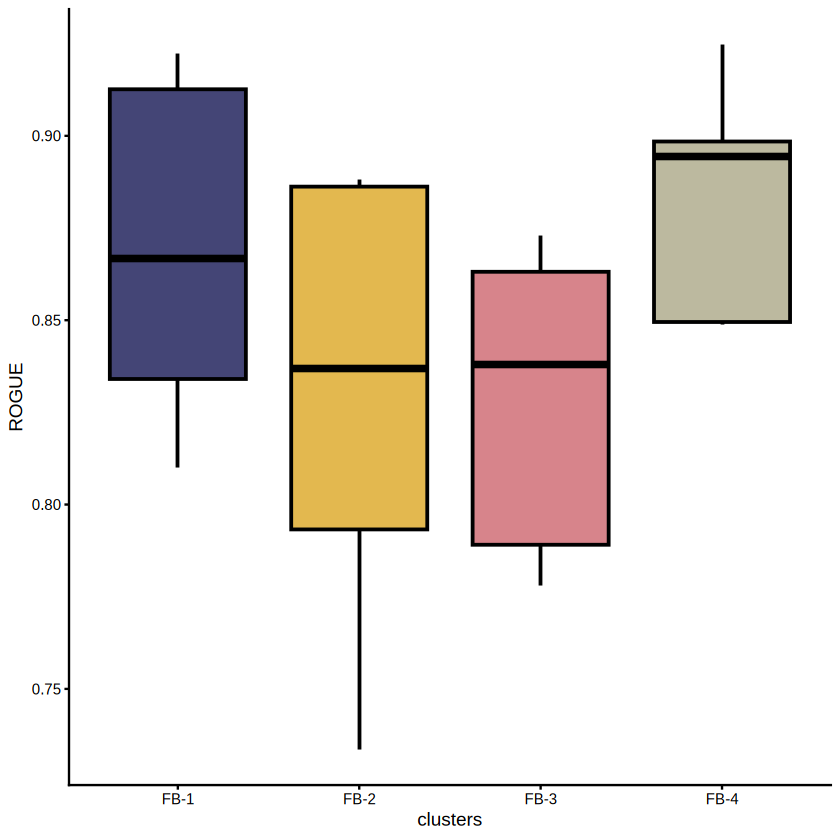

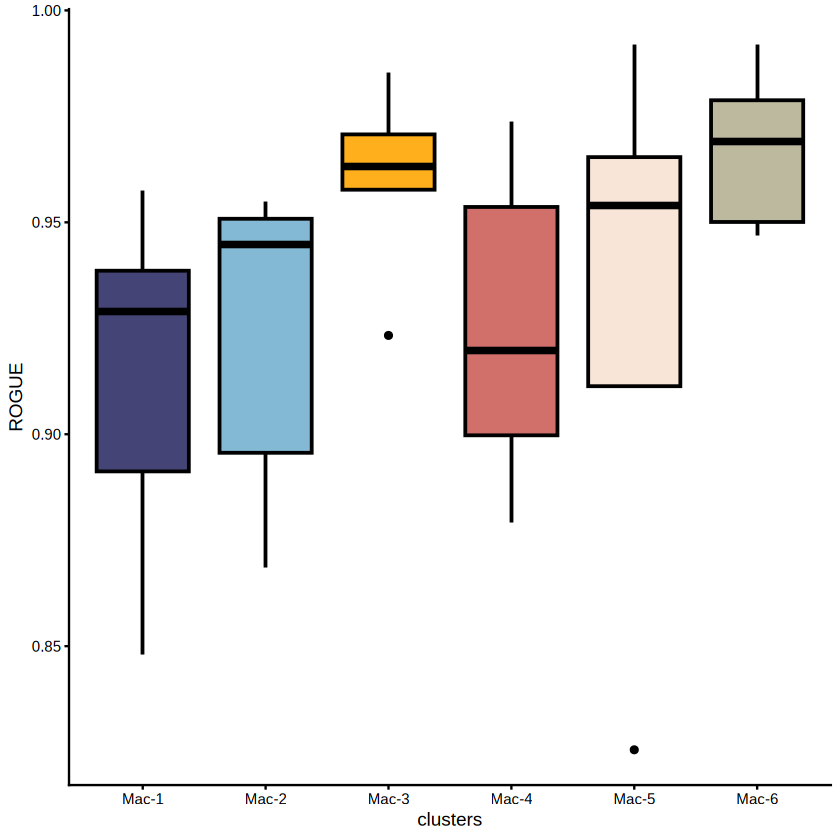

In [18]:
#S4f
suppressMessages(library(ROGUE))
suppressMessages(library(ggplot2))
suppressMessages(library(tidyverse))
rogue.res <- readRDS("data/ECrogue.Rds")
p <- rogue.boxplot(rogue.res)
p1 <-ggplot(p1$data, aes(x = clusters, y = ROGUE)) +
 geom_boxplot(aes(fill = clusters), color = "black", linewidth = 0.8) +
 scale_fill_manual(values = pal(5)) + # custom fill colors
 theme_classic() + # built-in black axes and border
 theme(
 legend.position = "none",
 axis.text = element_text(color = "black"), # axis textcolors
 axis.ticks = element_line(color = "black") # axis tickcolors
 )
p1
ggsave("S4f_EC_RUGUE.pdf",
 p1,path = "plot/figureS4/",width=3,height=3,create.dir = T)
rogue.res <- readRDS("data/FBrogue.Rds")
p <- rogue.boxplot(rogue.res)
p2 <-ggplot(p$data, aes(x = clusters, y = ROGUE)) +
 geom_boxplot(aes(fill = clusters), color = "black", linewidth = 0.8) +
 scale_fill_manual(values = pal(4)) + # custom fill colors
 theme_classic() + # built-in black axes and border
 theme(
 legend.position = "none",
 axis.text = element_text(color = "black"), # axis textcolors
 axis.ticks = element_line(color = "black") # axis tickcolors
 )
p2
ggsave("S4f_FB_RUGUE.pdf",
 p2,path = "plot/figureS4/",width=3,height=3,create.dir = T)
rogue.res <- readRDS("data/Macrogue.Rds") 
p <- rogue.boxplot(rogue.res)
p$data$clusters <- gsub("Macrophage","Mac",p$data$clusters)
p3 <-ggplot(p$data, aes(x = clusters, y = ROGUE)) +
 geom_boxplot(aes(fill = clusters), color = "black", linewidth = 0.8) +
 scale_fill_manual(values = pal(6)) + # custom fill colors
 theme_classic() + # built-in black axes and border
 theme(
 legend.position = "none",
 axis.text = element_text(color = "black"), # axis textcolors
 axis.ticks = element_line(color = "black") # axis tickcolors
 )
p3
ggsave("S4f_Mac_RUGUE.pdf",
 p3,path = "plot/figureS4/",width=3,height=3,create.dir = T)
 
